# Attention Variants -- Sliding Window, Sparse, Differential

Full attention is a circle. Every token sees every token, and memory pays the price. Four variants bend the shape of the circle and recover half the cost.

## Problem Definition

Full attention costs `O(N^2)` memory and `O(N^2)` compute in sequence length.

Three class of variants change the topology of the attention matrix itself:
1. Sliding window attention (SWA). Each token attends to a fixed window of neighbors, not the full prefix. Memory and compute drop to `O(N * W)` where `W` is the window.
2. Sparse/block attention.  Only selected pairs `(i, j)` get scored, the rest are forced to zero weight.
3. Differential attention. Compute two attention maps with separate Q/K projections, subtract one from the other. Kill the "attention sink" that bleeds weight into the first few tokens. 

## Basic Concept

### Sliding Window Attention

* KV cache shrinks with SWA.
  Only the last W tokens of K and V need to be kept per layer.

* Quality cost.
  SWA-only transformers struggle with long-range retrieval. The ifx: interleave SWA layers with full-attention layers.

### Sparse / Block Attention

Pick an `N x N` sparsity pattern ahead of time. Three canonical shapes:
1. Local + Strided. Local window + every stride-th token before that.
2. Longformer / BigBird.  Local window + a small set of global tokens, (eg. [CLS])
3. Native Sparse Attention.  Learn which blocks of `(Q, K)` matter

### Differential Attention

```
Split K, Q into (K1, K2), (Q1, Q2)
A1 = softmax(Q1 @ K1^T / sqrt(d))
A2 = softmax(Q2 @ K2^T / sqrt(d))
DiffAttn = (A1 - lambda * A2) * V
```

### Variant Comparison

| Variant | Compute | KV cache | Quality vs full | Production use |
|---------|---------|----------|-----------------|----------------|
| Full attention | O(N²) | O(N) per layer | baseline | every model's default layer |
| SWA (window 1024) | O(N·W) | O(W) per layer | -0.1 ppl, good with global layers | Gemma 2/3, Phi-3-Long |
| Local + strided sparse | O(N·√N) | mixed | similar to SWA | OpenAI sparse transformer, Longformer |
| BigBird (local + global + random) | O(N) approx | mixed | matches full at 2× context | early long-context BERT |
| Native Sparse (DeepSeek-V3.2) | O(N · active fraction) | O(N) | within 0.05 ppl | DeepSeek-V3.2, 2025 |
| Differential | O(2·N²) | O(2N) | -5 to -10% ppl | DIFF Transformer, early 2026 models |

# Build your Own

In [2]:
import math

NEG_INF = float("-inf")

def causal_mask(n):
    N = [[NEG_INF] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1):
            N[i][j] = 0
    return N

def swa_mask(n, window):
    M = [[NEG_INF] * n for _ in range(n)]
    for i in range(n):
        lo = max(0, i - window + 1)
        for j in range(lo, i + 1):
            M[i][j] = 0.0
    return M

def strided_mask(n, window, stride):
    M = [[NEG_INF] * n for _ in range(n)]
    for i in range(n):
        lo = max(0, i - window + 1)
        for j in range(lo, i + 1):
            M[i][j] = 0.0
        for j in range(0, i + 1, stride):
            M[i][j] = 0.0
    return M



==================Attention mask patterns===================


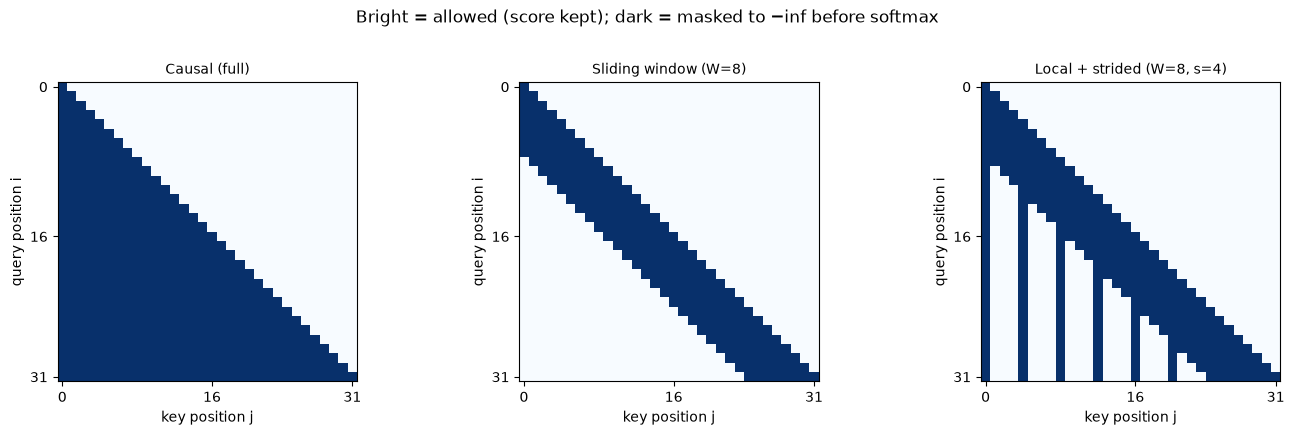

In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path("../../00_Common").resolve()))
from user_tools import SectionPrinter

import matplotlib.pyplot as plt
import numpy as np

N = 32
WINDOW = 8
STRIDE = 4

mask_specs = [
    ("Causal (full)", causal_mask(N)),
    (f"Sliding window (W={WINDOW})", swa_mask(N, WINDOW)),
    (f"Local + strided (W={WINDOW}, s={STRIDE})", strided_mask(N, WINDOW, STRIDE)),
]


def mask_to_vis(mask):
    """0.0 = allowed, NEG_INF = blocked → 1/0 for imshow."""
    return np.array([[1.0 if v == 0.0 else 0.0 for v in row] for row in mask])


with SectionPrinter("Attention mask patterns"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    for ax, (title, mask) in zip(axes, mask_specs):
        vis = mask_to_vis(mask)  # row i = query i, col j = key j
        ax.imshow(vis, cmap="Blues", origin="upper", vmin=0, vmax=1, aspect="equal")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("key position j")
        ax.set_ylabel("query position i")
        ax.set_xticks([0, N // 2, N - 1])
        ax.set_yticks([0, N // 2, N - 1])

    fig.suptitle(
        "Bright = allowed (score kept); dark = masked to −inf before softmax",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()